In [5]:
!pip install --user polars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 MB 128.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [polars]2m1/2 [polars]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib as plt

In [3]:
import polars as pl
path_train = "/fs/ess/PAS2159/HughesLab2/ANITA_DATA/parquet_for_fitting/processed_training_data.parquet"
schema = pl.scan_parquet(path_train).collect_schema()
for name, dtype in schema.items():
    print(f"{name:30s} {dtype}")

import os
print(os.path.exists(path_train))

## One thing I saw while looking up how to work with polars was that 
## it is "lazy"? The pl.scan line does not load the data from the file
## that we gave it, it just looks at the structure through collect_schema
## This was the easiest way that I saw to check if the file exists, 
## if I can access it, what the columns have, and what data is in each
## The result was 43 columns including raw_waveforms which is to be expected i think


run                            Int64
event                          Int64
weight                         Float64
phi_estimated                  Float64
theta_estimated                Float64
thetaNu                        Float64
phiNu                          Float64
mctheta                        Float64
mcphi                          Float64
snr_vpol                       Float64
snr_hpol                       Float64
energy                         Float64
latitude                       Float64
longitude                      Float64
altitude                       Float64
heading                        Float64
maxSNRAtDigitizerV             Float64
maxSNRAtDigitizerH             Float64
maxSNRAtTriggerH               Float64
maxSNRAtTriggerV               Float64
sin_phi                        Float64
cos_phi                        Float64
sin_theta                      Float64
cos_theta                      Float64
sin_phi_nu                     Float64
cos_phi_nu                   

In [4]:
df = pl.read_parquet(path_train)
print("rows, cols:", df.shape)

## here, unlike the above cell, the file is "read". We pull every row
## into memory, and then defining it as a df (or dataframe).
## The print is just to make sure the shape of our df looks about right
## in the above cell, we got back 43 columns, and yay, we got 43 columns
## in this command as well. 
## The shape shows that there are roughly 42,000 events with 43 columns per event
## In comparison to the data that Aaron used in his poster, he started
## with 400K events and after a weight cut went to 68K. It is safe to 
## assume that the data that we are using here has already gone thru a cut
## Can I confirm this?? 

rows, cols: (41959, 43)


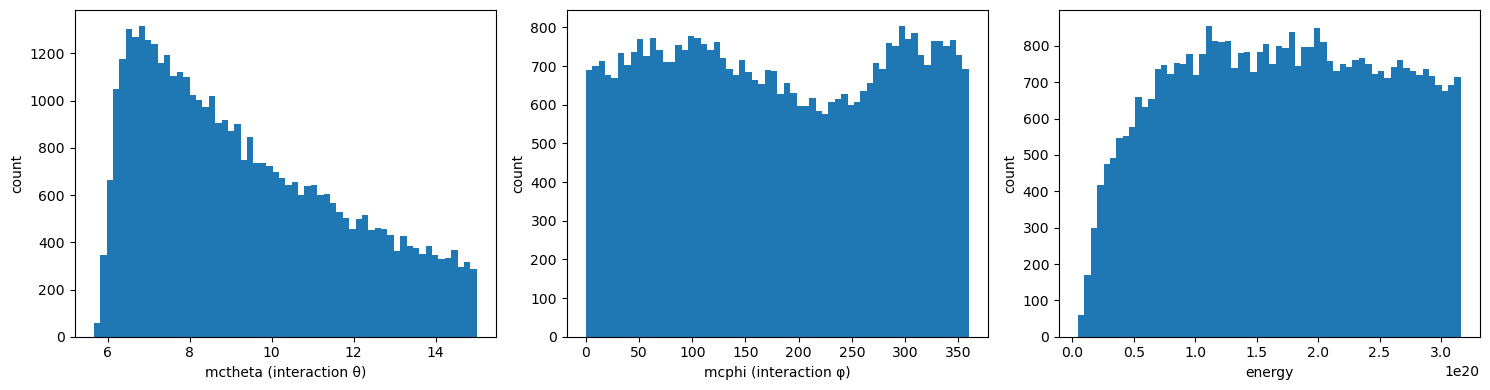

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["mctheta"].to_numpy(), bins=60)
axes[0].set_xlabel("mctheta (interaction θ)")

axes[1].hist(df["mcphi"].to_numpy(), bins=60)
axes[1].set_xlabel("mcphi (interaction φ)")

axes[2].hist(df["energy"].to_numpy(), bins=60)
axes[2].set_xlabel("energy")

for ax in axes:
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## This displays three of our five targets (mctheta, mcphi, nutheta,
## nuphi, energy), here we show mctheta, mcphi, and energy.
## mctheta covers a range of about 5-16 degrees. 
## I don't think it is too surprising that theta does not have the same 
## 0-360 degree range that phi has given the way these angles act in 
## sph coordinates
## For the sake of my learning, I will go over the output we get
## MCtheta is right skewed, with a peak around 6-7 degrees.
## MCtheta is the angle from the balloon's perspective where the 
## neutrino interaction in the ice was detected.
## From the way the histogram looks, it seems that events past the 
##10-degree marks are much more difficult to detect than in the 6-8 region
## Is there a certain point where it becomes nonphysical? Yes, where?
## MCphi ranges from 0-360 with a drop around 200 degrees and two bumps
## at 50-100 and 300 degrees. Physically, phi is the direction around the
## balloon, physically, any direction should be just as probable, so why
## Is there a dip between 150-250 degrees? From my initial expectation, 
## This should be a relatively flat distribution. Is that dip normal?
## Is it too much of a dip, or is this about expected?
## Finally, energy! The count grows steeply as energy increases and flattens out
## If this were real data, I would assume that the energy should fall off
## There should not be this many high-energy events, but this is simulated
## I think that if the distribution was like in nature, we would have far too
## many low-energy events and not nearly enough higher-energy ones. 


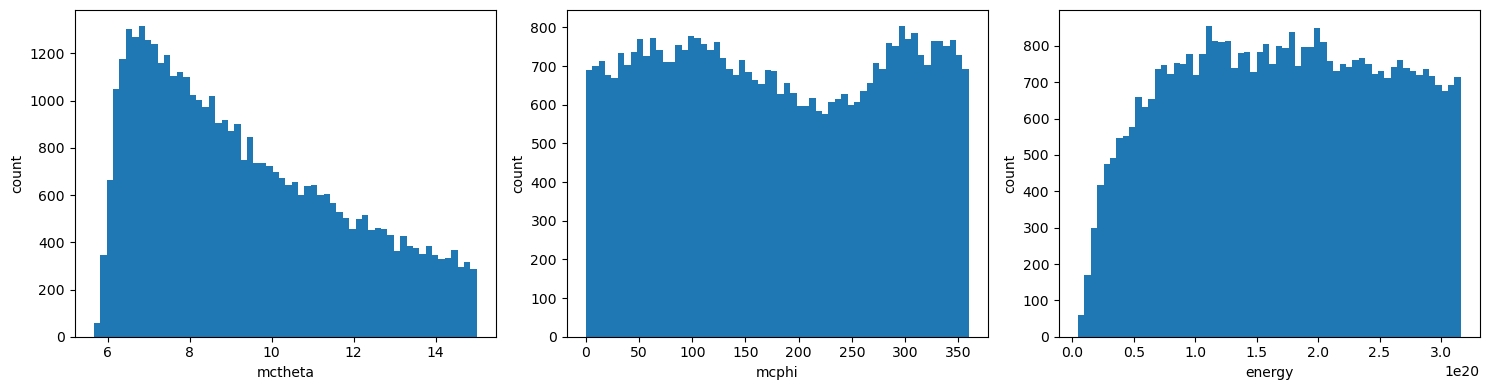

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ["mctheta", "mcphi", "energy"]):
    ax.hist(df[col].to_numpy(), bins = 60)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## this cell and the cell above produce the exact same results
## they are just different ways to do the same thing
## The first process is a bit more redundant and likely would not hold
## up if more was introduced into the picture

In [7]:
import numpy as np

one event shape: (48, 100, 2)


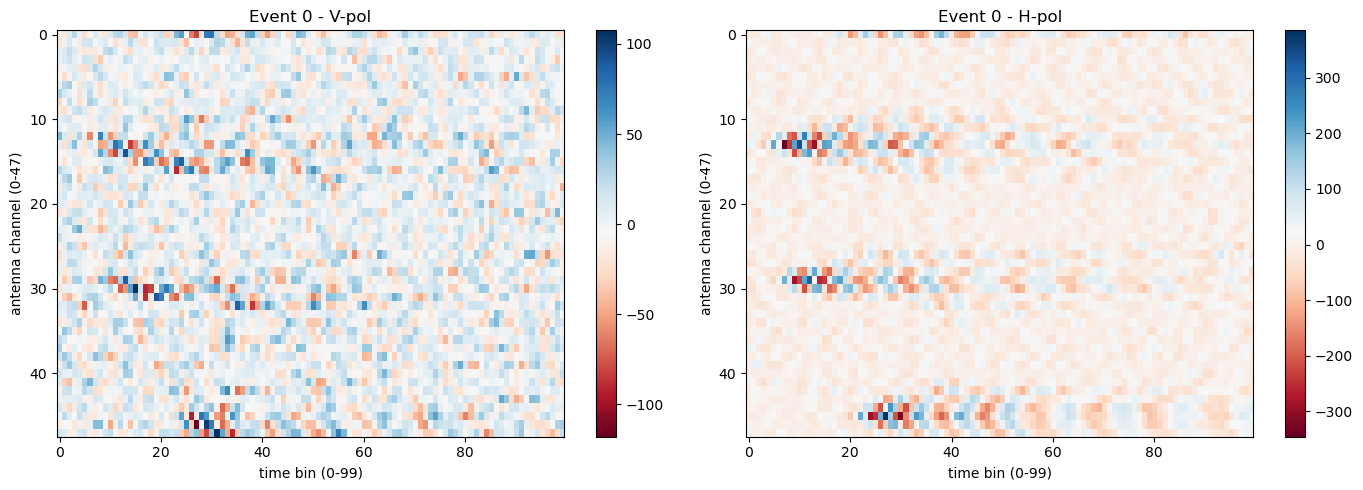

In [11]:
event0 = df["raw_waveforms"][0].to_numpy()
print("one event shape:", event0.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for pol, name in [(0, "V-pol"), (1, "H-pol")]:
    im = axes[pol].imshow(event0[: , :, pol], aspect="auto", cmap ="RdBu")
    axes[pol].set_title(f"Event 0 - {name}")
    axes[pol].set_xlabel("time bin (0-99)")
    axes[pol].set_ylabel("antenna channel (0-47)")
    fig.colorbar(im, ax=axes[pol])
plt.tight_layout()
plt.show()


## I had no idea what an event actually looked like! So, I wanted to 
## play around with what just one event from the data would look like
## Conceptually, I am trying to figure out why the h-pol and v-pol look diff
## Each row of the heatmap is one of the 48 antennas. and each column
## is each one of 100 time steps. 
## This looks like the plot on the CNN poster. I assume that at some point, 
## We want to teach something to read these, I think?

In [ ]:
## This is my first step to teaching myself how to do any of this!
## There are a couple of things that I wanted to do with this document
## 1 - I want to first confirm that I can even access the data!
## Making sure I know how to pull it. 
## 2 - figure out what is in the data, I wanted to know the names of 
## columns, types, shapes
## 3 - check shape of the data itself, looking at the histograms and 
## their distributions
## 4 - What on earth does a signal look like